In [1]:
import ast
def extract_L_set(filepath):
    l_set = []
    capture = False
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
        
            # Start capturing when we see the header
            if line.startswith("L set:"):
                capture = True
                continue
        
            # Stop capturing when we reach the B vector
            if line.startswith("B vector:"):
                capture = False
                break
            
            # If we are in the capture zone and the line looks like a list
            if capture and line.startswith("["):
                # ast.literal_eval safely converts the string "[1, 2...]" into a Python list
                row = ast.literal_eval(line)
                l_set.append(row)
    return l_set

In [2]:
import numpy as np

# ===========================
# Complete dataset
# ===========================

train_filePath = '../ED_Calculation/2003_2023/results/finalize_L_set_from_2003_to_2023.txt'
train_data= np.array(extract_L_set(train_filePath))
test_filepath = "../ED_Calculation/2024_current/results/final_result_df_2024_2025.txt"
test_data = np.array(extract_L_set(test_filepath))

X_full = train_data[:, :5]
y_full = train_data[:, 5]

X_test = test_data[:, :5]
y_test = test_data[:, 5]

y_full_bin = (y_full > 0).astype(int).reshape(-1, 1)
y_test_bin = (y_test > 0).astype(int).reshape(-1, 1)

split_idx = int(0.8 * len(X_full))
X_train = X_full[:split_idx]
y_train = y_full_bin[:split_idx]
X_val   = X_full[split_idx:]
y_val   = y_full_bin[split_idx:]

mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
X_train_n = (X_train - mean) / std
X_val_n   = (X_val   - mean) / std
X_test_n  = (X_test  - mean) / std

In [3]:
# ------------- Network (16 hidden) -------------
input_size  = 5
hidden_size = 16
output_size = 1

np.random.seed(0)
W_h = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
W_o = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
b_o = np.zeros((1, output_size))
B_h = np.random.randn(1, hidden_size) * 0.01   # small random biases
print(f"\n Hidden weight=> {W_h}")
print(f"\n Output weight=> {W_o}")

def hidden_sigmoid(x):
    return 1.0 / (1.0 + np.exp( -x ))

def forward(X):
    H = hidden_sigmoid(X @ W_h + B_h)
    logits = H @ W_o + b_o       # linear output
    return H, logits

def binary_cross_entropy_with_logits(logits, y_true):
    max_logit = np.clip(logits, -100, 100)
    return np.mean(np.maximum(max_logit, 0) - max_logit * y_true + np.log(1 + np.exp(-np.abs(max_logit))))


 Hidden weight=> [[ 1.11568467  0.25308164  0.61900825  1.4172653   1.18114738 -0.6180848
   0.60088868 -0.0957267  -0.06528133  0.25968529  0.09110115  0.91976332
   0.48132252  0.07695404  0.28072376  0.21103417]
 [ 0.94493858 -0.12975348  0.1980014  -0.54017758 -1.61465253  0.4133847
   0.54671746 -0.46938637  1.43551887 -0.91982162  0.02894023 -0.11838546
   0.96941469  0.92930408  0.09799736  0.23917098]
 [-0.56148501 -1.25276568 -0.22003896  0.09888377  0.77810415  0.76045179
  -0.24496699 -0.19119305 -0.66316312 -0.8980982  -1.07914002  1.23377869
  -0.32233234 -0.27706252 -0.79233736  0.49172808]
 [-1.02071862 -0.13454877 -0.56634278  0.24469863 -0.32306154 -0.74669736
  -0.01782401  0.27090086  0.04206919  0.19130003 -0.40118052 -0.22941766
  -0.42530133 -0.22740139 -0.51427886 -1.09179698]
 [ 0.11221415 -0.25410858 -1.03102796  0.2926892  -0.57382587  0.03285315
   0.46111736  0.08157596  0.72062027 -0.78097242  0.2544632  -0.43311193
  -0.55074047 -0.36609667 -0.19704312  0

In [4]:
# ------------- Training -------------
learning_rate = 0.052
epochs = 250
patience = 5
best_val_loss = np.inf
patience_counter = 0
epoch_log = []

for epoch in range(epochs):
    H, logits = forward(X_train_n)
    loss = binary_cross_entropy_with_logits(logits, y_train)

    p = 1.0 / (1.0 + np.exp(-logits))   # logistic sigmoid
    d_logits = (p - y_train) / X_train_n.shape[0]

    dW_o = H.T @ d_logits
    db_o = np.sum(d_logits, axis=0, keepdims=True)

    dH = d_logits @ W_o.T
    dZ_h = dH * ( H * (1 - H))

    dW_h = X_train_n.T @ dZ_h
    dB_h = np.sum(dZ_h, axis=0, keepdims=True)

    W_o -= learning_rate * dW_o
    b_o -= learning_rate * db_o
    W_h -= learning_rate * dW_h
    B_h -= learning_rate * dB_h

    _, val_logits = forward(X_val_n)
    val_loss = binary_cross_entropy_with_logits(val_logits, y_val)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Training accuracy
    train_pred = (logits > 0).astype(int)
    train_acc = np.mean(train_pred == y_train)
    val_pred = (val_logits > 0).astype(int)
    val_acc = np.mean(val_pred == y_val)
    epoch_log.append((epoch+1, loss, val_loss, train_acc, val_acc))
    print(f"Epoch {epoch+1:5d}/{epochs} ______ loss: {loss:.6f} -- acc: {train_acc:.2%} -- val_loss: {val_loss:.6f}  -- val_acc: {val_acc:.2%}")

Epoch     1/250 ______ loss: 0.801332 -- acc: 53.45% -- val_loss: 0.786009  -- val_acc: 51.72%
Epoch     2/250 ______ loss: 0.790147 -- acc: 53.45% -- val_loss: 0.776084  -- val_acc: 48.28%
Epoch     3/250 ______ loss: 0.780033 -- acc: 53.45% -- val_loss: 0.767127  -- val_acc: 48.28%
Epoch     4/250 ______ loss: 0.770910 -- acc: 53.45% -- val_loss: 0.759061  -- val_acc: 48.28%
Epoch     5/250 ______ loss: 0.762698 -- acc: 53.45% -- val_loss: 0.751812  -- val_acc: 48.28%
Epoch     6/250 ______ loss: 0.755322 -- acc: 54.31% -- val_loss: 0.745309  -- val_acc: 48.28%
Epoch     7/250 ______ loss: 0.748709 -- acc: 54.31% -- val_loss: 0.739486  -- val_acc: 48.28%
Epoch     8/250 ______ loss: 0.742790 -- acc: 53.45% -- val_loss: 0.734278  -- val_acc: 48.28%
Epoch     9/250 ______ loss: 0.737500 -- acc: 55.17% -- val_loss: 0.729626  -- val_acc: 48.28%
Epoch    10/250 ______ loss: 0.732779 -- acc: 55.17% -- val_loss: 0.725477  -- val_acc: 48.28%
Epoch    11/250 ______ loss: 0.728570 -- acc: 55.1

In [5]:

# ------------- Test -------------
_, test_logits = forward(X_test_n)
test_pred = (test_logits > 0).astype(int)
acc = np.mean(test_pred.flatten() == y_test_bin.flatten())
print(f"\nTest Direction Accuracy: {acc:.2%}")

import pandas as pd
# Create a comparison table
results_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': test_logits.flatten(),
    'Direction': (((y_test > 0) & (test_logits.flatten() > 0)) | ((y_test < 0) & (test_logits.flatten() < 0))).astype(int)
})

print("Predictions for the 2024-2025 Test Set:")
display(results_df)
count_ones = results_df['Direction'].value_counts()[1]
print(results_df['Direction'].value_counts())
print(f"Total right direction => {count_ones}, {(count_ones/len(test_logits.flatten()))*100:.2f}%")


Test Direction Accuracy: 63.64%
Predictions for the 2024-2025 Test Set:


,Actual Value,Predicted Value,Direction
0,-0.017473,0.165027,0
1,-0.339443,0.210286,0
2,0.031541,0.436623,1
3,-0.215161,0.075943,0
4,-0.087107,0.137958,0
5,0.485383,0.324927,1
6,-0.220254,-0.116706,1
7,0.307394,0.572391,1
8,0.306878,0.159158,1
9,0.113420,0.087180,1


Direction
1    7
0    4
Name: count, dtype: int64
Total right direction => 7, 63.64%


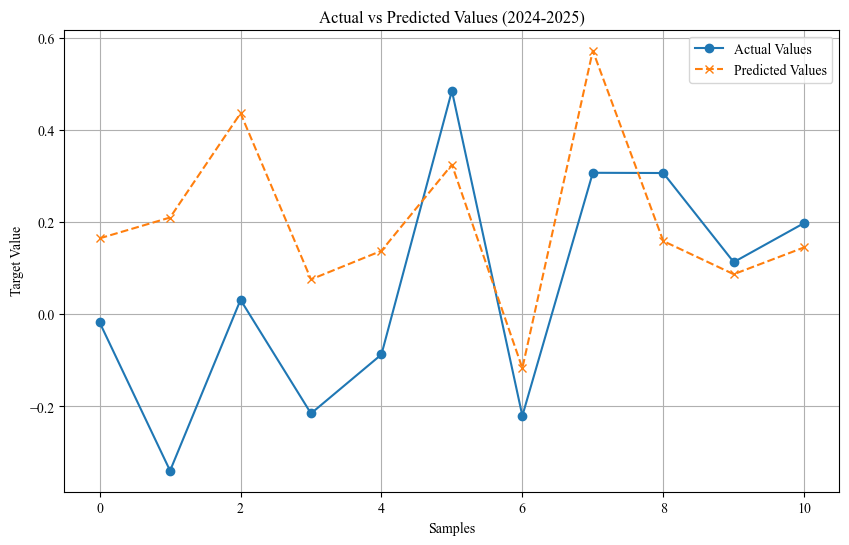

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test)), y_test, label="Actual Values", marker="o")
plt.plot(range(len(test_logits)), test_logits.flatten(), label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values (2024-2025)")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()


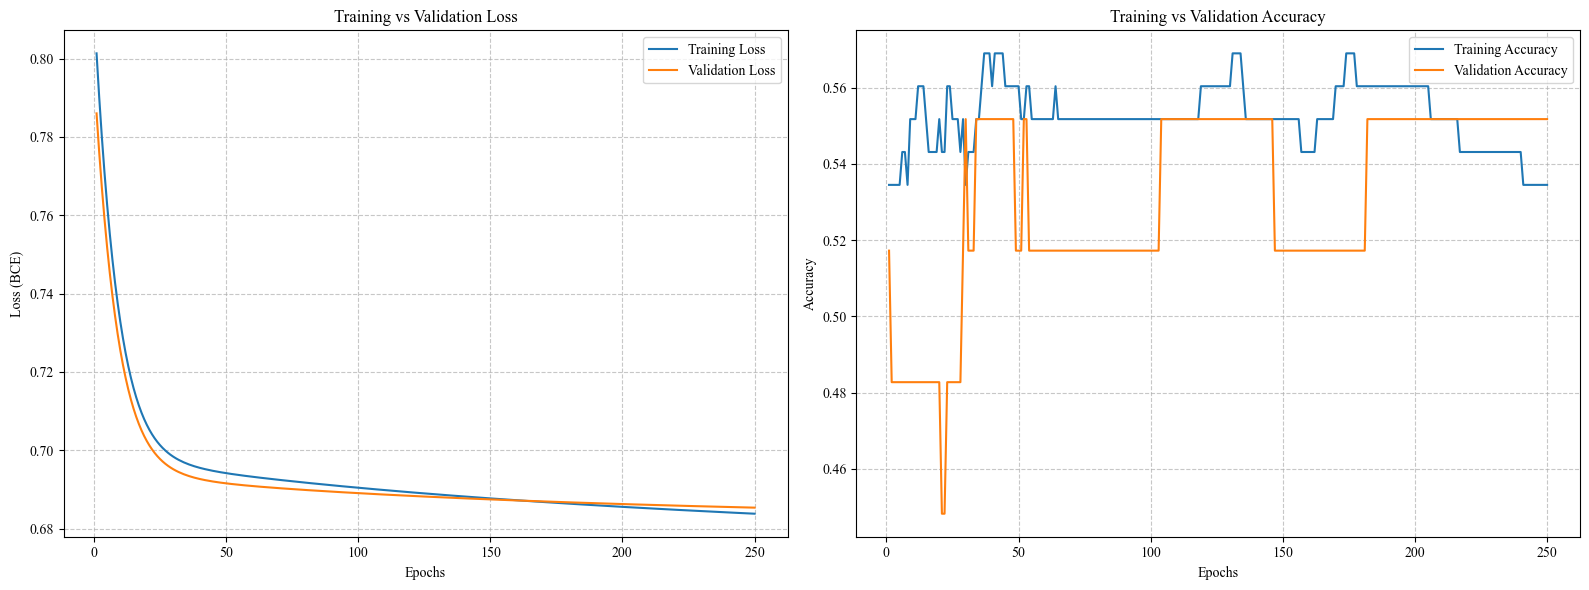

In [7]:
import matplotlib.pyplot as plt


# Extract data from the epoch_log list
# epoch_log contains tuples: (epoch, loss, val_loss, train_acc, val_acc)
epochs_list = [entry[0] for entry in epoch_log]
train_bce_list = [entry[1] for entry in epoch_log]
val_bce_list = [entry[2] for entry in epoch_log]
train_acc_list = [entry[3] for entry in epoch_log]
val_acc_list = [entry[4] for entry in epoch_log]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: BCE Loss
ax1.plot(epochs_list, train_bce_list, label='Training Loss')
ax1.plot(epochs_list, val_bce_list, label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (BCE)')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Accuracy
ax2.plot(epochs_list, train_acc_list, label='Training Accuracy')
ax2.plot(epochs_list, val_acc_list, label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()